# Titanic data set

<img src="data/titanic.jpg" width=300>

Reference: https://medium.com/@sayahfares19/hands-on-data-analysis-on-titanic-dataset-using-pandas-646a41edf81

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set(style="ticks", font='Hiragino Sans')
%matplotlib inline

## Read the data

In [2]:
titanic_df = pl.read_csv("data/titanic.csv")

In [3]:
titanic_df.head()

survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
i64,i64,str,str,f64,i64,i64,str,f64,str,str
0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S"""
1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C"""
1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S"""
1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S"""
0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S"""


In [4]:
titanic_df.glimpse()

Rows: 891
Columns: 11
$ survived <i64> 0, 1, 1, 1, 0, 0, 0, 0, 1, 1
$ pclass   <i64> 3, 1, 3, 1, 3, 3, 1, 3, 3, 2
$ name     <str> 'Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry', 'Moran, Mr. James', 'McCarthy, Mr. Timothy J', 'Palsson, Master. Gosta Leonard', 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)', 'Nasser, Mrs. Nicholas (Adele Achem)'
$ sex      <str> 'male', 'female', 'female', 'female', 'male', 'male', 'male', 'male', 'female', 'female'
$ age      <f64> 22.0, 38.0, 26.0, 35.0, 35.0, null, 54.0, 2.0, 27.0, 14.0
$ sibsp    <i64> 1, 1, 0, 1, 0, 0, 0, 3, 0, 1
$ parch    <i64> 0, 0, 0, 0, 0, 0, 0, 1, 2, 0
$ ticket   <str> 'A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450', '330877', '17463', '349909', '347742', '237736'
$ fare     <f64> 7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51.8625, 21.075, 11.1333, 30.0708
$ cabin    <str> 

In [5]:
null_val = titanic_df.null_count().transpose(include_header=True, header_name="column", column_names=["null_count"])
null_val

column,null_count
str,u32
"""survived""",0
"""pclass""",0
"""name""",0
"""sex""",0
"""age""",177
…,…
"""parch""",0
"""ticket""",0
"""fare""",0


## Who were the passengers on the Titanic?

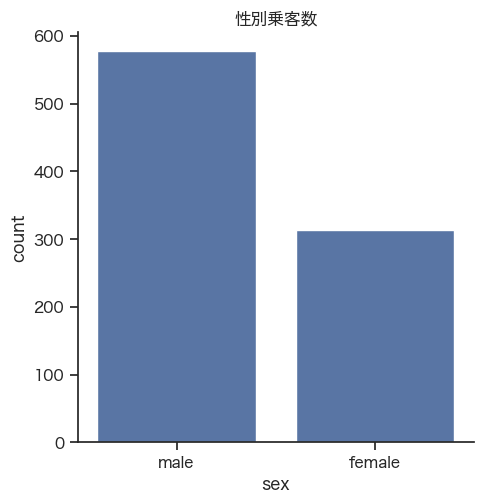

In [6]:
sns.catplot(x='sex', data=titanic_df, kind='count').set(title="性別乗客数")

Text(0.5, 1.0, '年齢別分布')

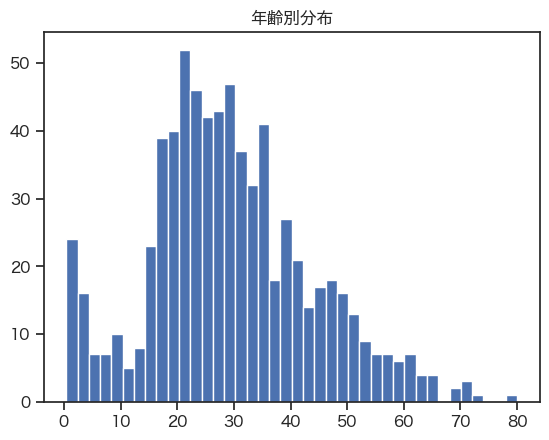

In [7]:
plt.hist(titanic_df['age'].drop_nulls(), bins=40)
plt.title("年齢別分布")

In [8]:
percent = 100 * null_val["null_count"] / len(titanic_df)
missing = pl.DataFrame({
    "column": null_val["column"],
    "Missing": null_val["null_count"],
    "%": percent
})
missing

column,Missing,%
str,u32,f64
"""survived""",0,0.0
"""pclass""",0,0.0
"""name""",0,0.0
"""sex""",0,0.0
"""age""",177,19.86532
…,…,…
"""parch""",0,0.0
"""ticket""",0,0.0
"""fare""",0,0.0


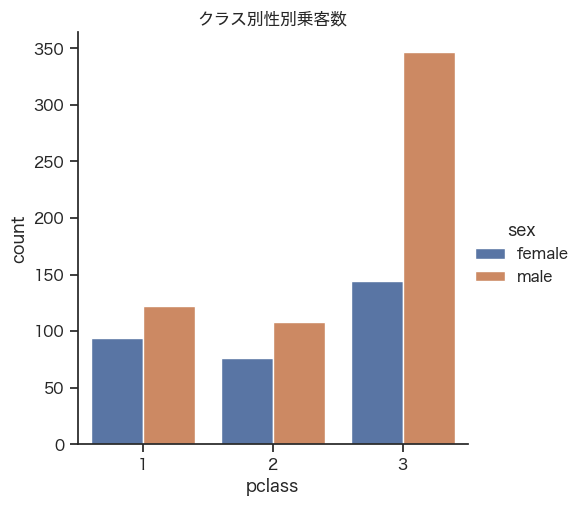

In [9]:
rel = sns.catplot(x='pclass', data=titanic_df, hue='sex', kind='count').set(title="クラス別性別乗客数")

In [10]:
titanic_df = titanic_df.with_columns(
    pl.when(pl.col("age") < 16)
    .then(pl.lit("child"))
    .otherwise(pl.col("sex"))
    .alias("person")
)

In [11]:
titanic_df.head()

survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,person
i64,i64,str,str,f64,i64,i64,str,f64,str,str,str
0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S""","""male"""
1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C""","""female"""
1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S""","""female"""
1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S""","""female"""
0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S""","""male"""


In [12]:
titanic_df['person'].unique()

person
str
"""child"""
"""male"""
"""female"""


In [13]:
titanic_df['person'].value_counts()

person,count
str,u32
"""male""",537
"""child""",83
"""female""",271


In [14]:
titanic_df['age'].mean()

29.69911764705882

## What deck were the passengers on and how does that relate to their class?

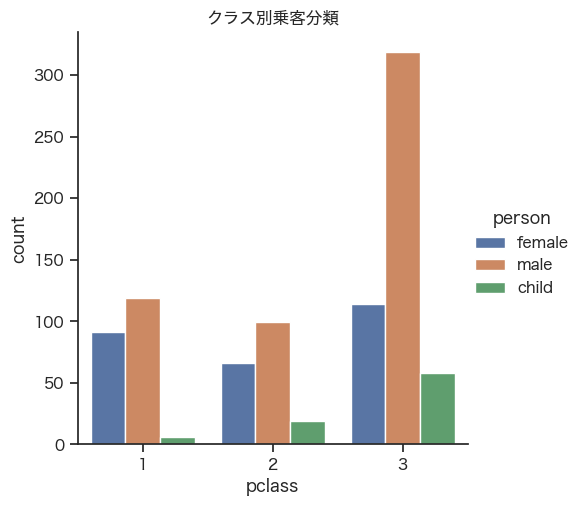

In [15]:
sns.catplot(x='pclass', data=titanic_df, hue='person', kind='count').set(title="クラス別乗客分類")

In [16]:
deck = titanic_df['cabin'].drop_nulls()
deck

cabin
str
"""C85"""
"""C123"""
"""E46"""
"""G6"""
"""C103"""
…
"""D35"""
"""B51 B53 B55"""
"""C50"""


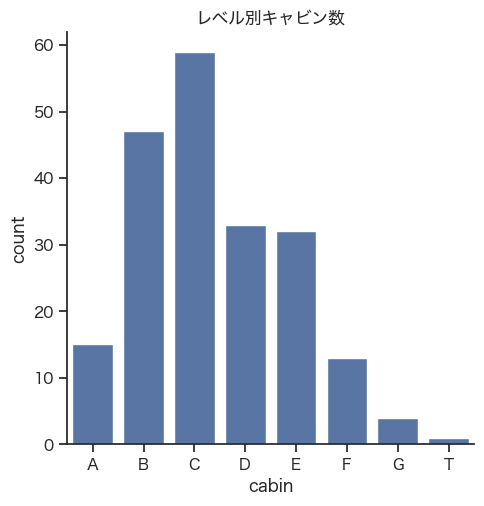

In [17]:
levels = []
for level in deck:
    levels.append(level[0])
cabin_df = pl.DataFrame({"cabin": levels}).sort("cabin")
sns.catplot(x='cabin', data=cabin_df, kind='count').set(title="レベル別キャビン数")

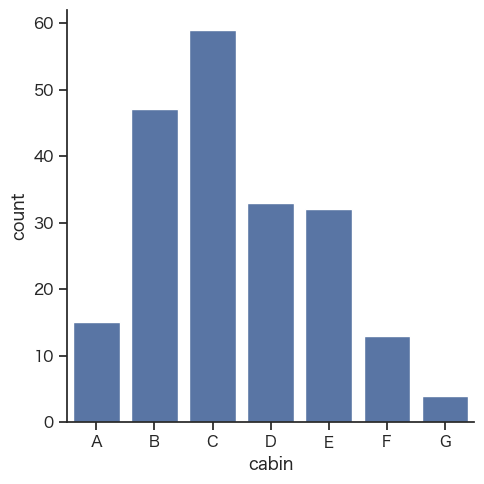

In [18]:
cabin_df = cabin_df.filter(pl.col("cabin") != "T")
sns.catplot(x='cabin', data=cabin_df, kind='count')

## Where did the passengers come from?

In [19]:
titanic_df['embarked'].unique()

embarked
str
null
"""C"""
"""Q"""
"""S"""


Cherbourg, Queenstown and Southhampton.

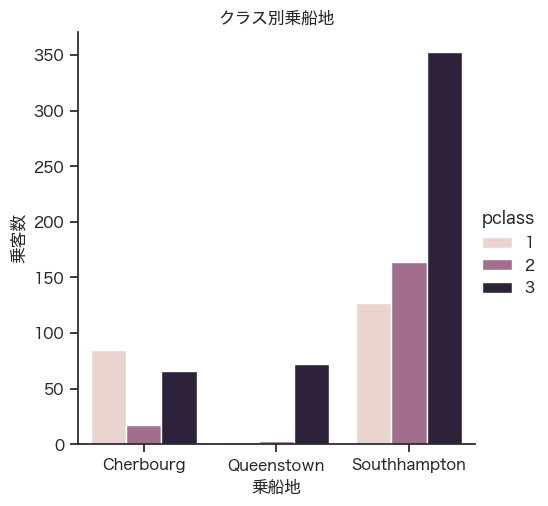

In [20]:
fg = sns.catplot(x='embarked', data=titanic_df, hue='pclass', kind='count', order=['C', 'Q', 'S'])
fg.set(title="クラス別乗船地", xlabel="乗船地", ylabel="乗客数")
fg.set_xticklabels(["Cherbourg", "Queenstown", "Southhampton"])

In [21]:
titanic_df = titanic_df.with_columns(
    (pl.col("sibsp") + pl.col("parch")).alias("alone")
)
titanic_df['alone']

alone
i64
1
1
0
1
0
…
0
0
3


In [22]:
titanic_df = titanic_df.with_columns(
    pl.when(pl.col("alone") > 0)
    .then(pl.lit("with family"))
    .otherwise(pl.lit("alone"))
    .alias("alone")
)
titanic_df.head()

survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,person,alone
i64,i64,str,str,f64,i64,i64,str,f64,str,str,str,str
0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S""","""male""","""with family"""
1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C""","""female""","""with family"""
1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S""","""female""","""alone"""
1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S""","""female""","""with family"""
0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S""","""male""","""alone"""


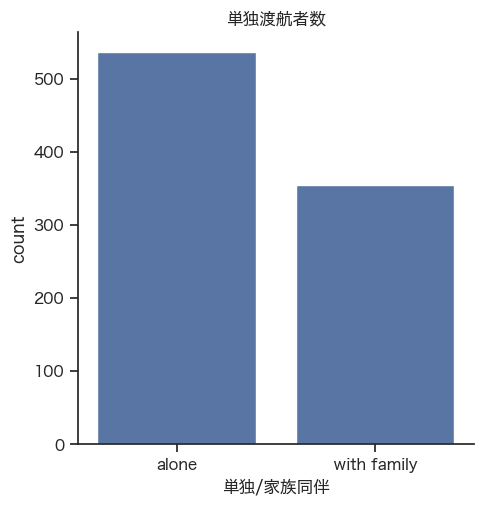

In [23]:
sns.catplot(titanic_df, x='alone', kind='count', order=['alone', 'with family']).set(title="単独渡航者数", xlabel="単独/家族同伴")

In [24]:
titanic_df = titanic_df.with_columns(
    pl.when(pl.col("survived") == 1)
    .then(pl.lit("Yes"))
    .otherwise(pl.lit("No"))
    .alias("survivor")
)
titanic_df.head()

survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,person,alone,survivor
i64,i64,str,str,f64,i64,i64,str,f64,str,str,str,str,str
0,3,"""Braund, Mr. Owen Harris""","""male""",22.0,1,0,"""A/5 21171""",7.25,null,"""S""","""male""","""with family""","""No"""
1,1,"""Cumings, Mrs. John Bradley (Fl…","""female""",38.0,1,0,"""PC 17599""",71.2833,"""C85""","""C""","""female""","""with family""","""Yes"""
1,3,"""Heikkinen, Miss. Laina""","""female""",26.0,0,0,"""STON/O2. 3101282""",7.925,null,"""S""","""female""","""alone""","""Yes"""
1,1,"""Futrelle, Mrs. Jacques Heath (…","""female""",35.0,1,0,"""113803""",53.1,"""C123""","""S""","""female""","""with family""","""Yes"""
0,3,"""Allen, Mr. William Henry""","""male""",35.0,0,0,"""373450""",8.05,null,"""S""","""male""","""alone""","""No"""


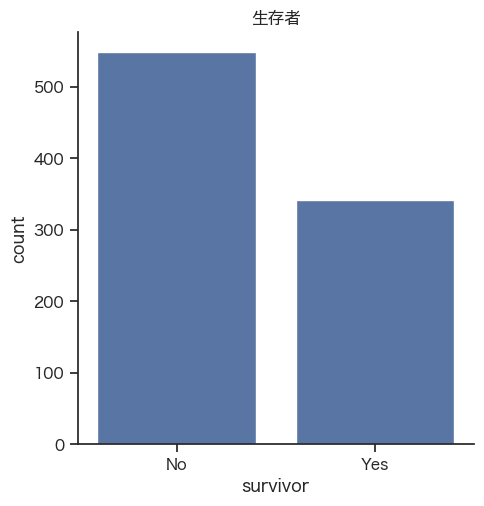

In [25]:
sns.catplot(titanic_df, x='survivor', kind='count').set(title="生存者")

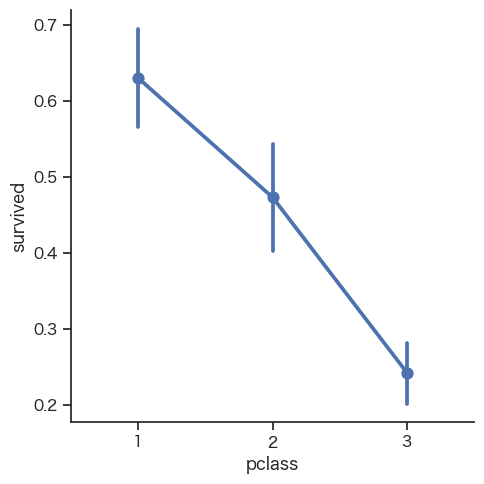

In [26]:
sns.catplot(titanic_df, x='pclass', y='survived', kind='point')

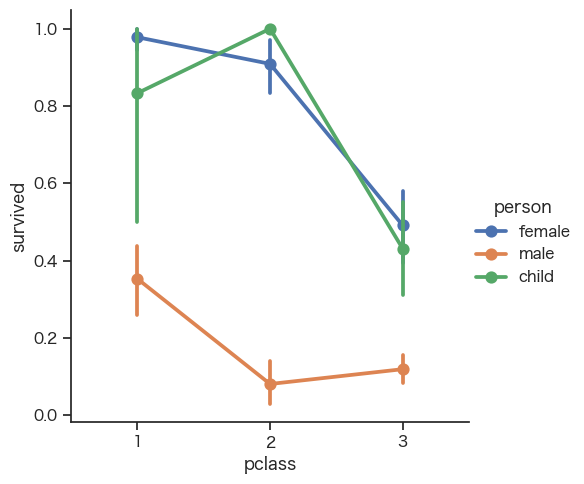

In [27]:
sns.catplot(data=titanic_df, x='pclass', y='survived', kind='point', hue='person')

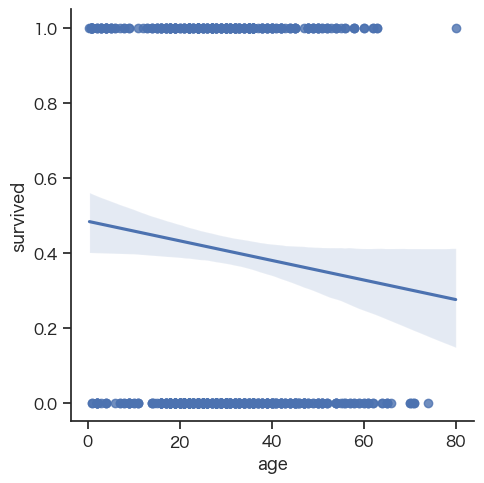

In [28]:
sns.lmplot(titanic_df, x='age', y='survived')

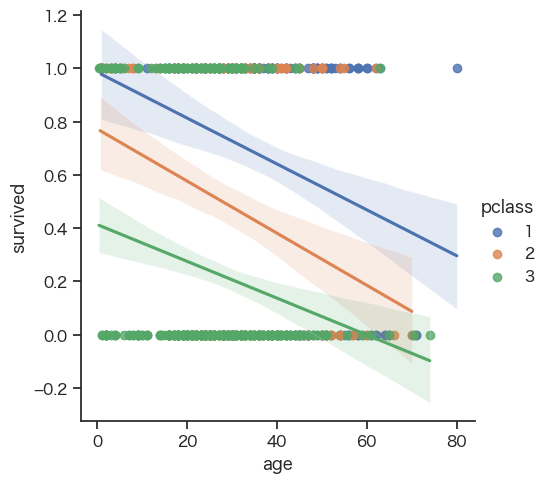

In [29]:
sns.lmplot(titanic_df, x='age', y='survived', hue='pclass')

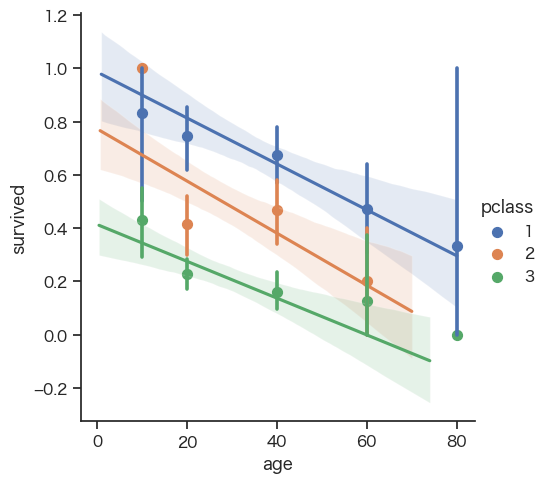

In [30]:
generations = [10, 20, 40, 60, 80]
sns.lmplot(data=titanic_df, x ='age', y='survived', hue='pclass', x_bins=generations)

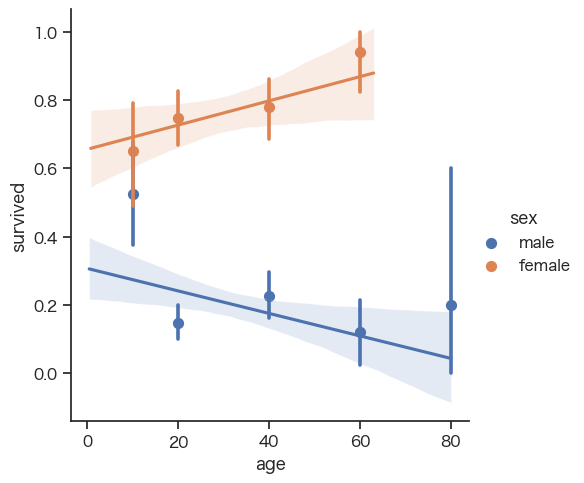

In [31]:
sns.lmplot(data=titanic_df, x ='age', y='survived', hue='sex', x_bins=generations)